In [6]:
%pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 1. Data Loading & Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set chart style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('data/retail_sales_dataset.csv')

# Preview the data and check data types
print("--- First 5 Rows Preview ---")
display(df.head())

print("\n--- Data Info & Missing Values Analysis ---")
df.info()

--- First 5 Rows Preview ---


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100



--- Data Info & Missing Values Analysis ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


# 2. Data Cleaning & Preparation

In [2]:
#Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

#Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

#Extract Month and Year for time-series analysis
df['Month_Year'] = df['Date'].dt.to_period('M')

print("\nData successfully cleaned and prepared for analysis!")

Number of duplicate rows: 0

Data successfully cleaned and prepared for analysis!


# 3. Business KPIs Calculation

In [3]:
# KPI 1: Total Revenue (Total Amount)
total_revenue = df['Total Amount'].sum()

# KPI 2: Total Number of Transactions
total_transactions = df['Transaction ID'].nunique()

# KPI 3: Average Order Value (AOV)
average_order_value = df['Total Amount'].mean()

# KPI 4: Average Customer Age
average_age = df['Age'].mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions}")
print(f"Average Order Value: ${average_order_value:.2f}")
print(f"Average Customer Age: {average_age:.1f} years old")

Total Revenue: $456,000.00
Total Transactions: 1000
Average Order Value: $456.00
Average Customer Age: 41.4 years old


# 4. Data Visualizations for GitHub

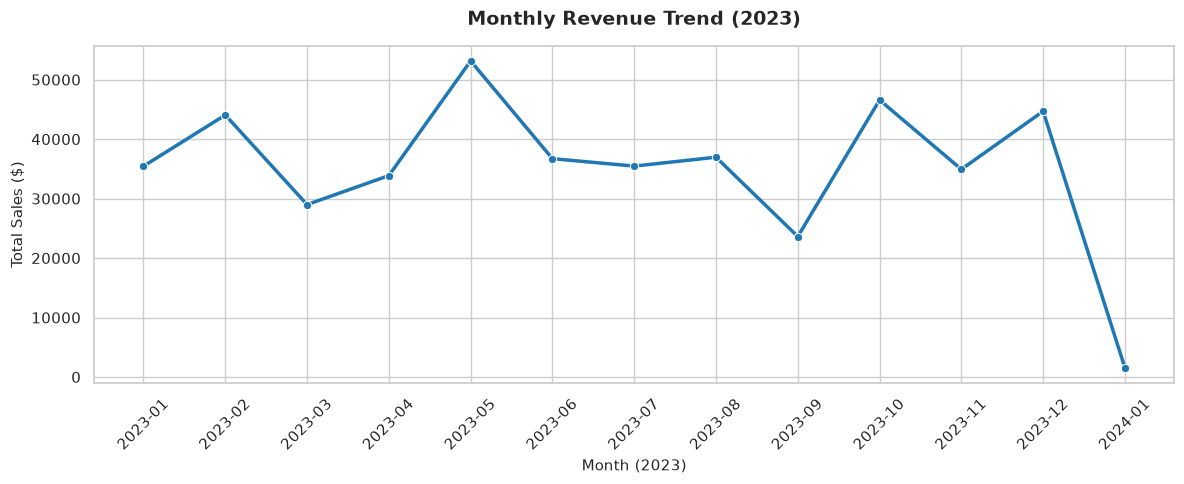

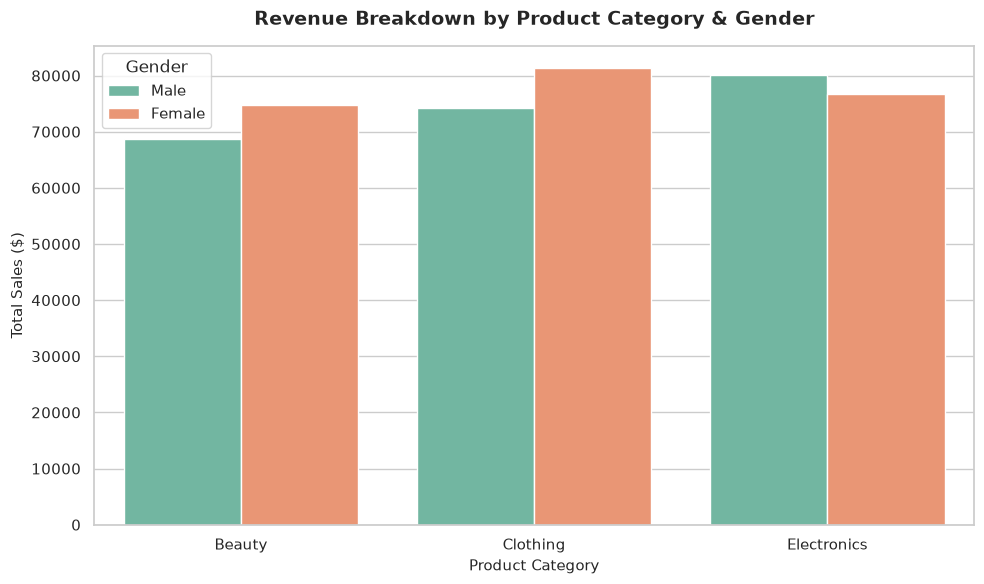

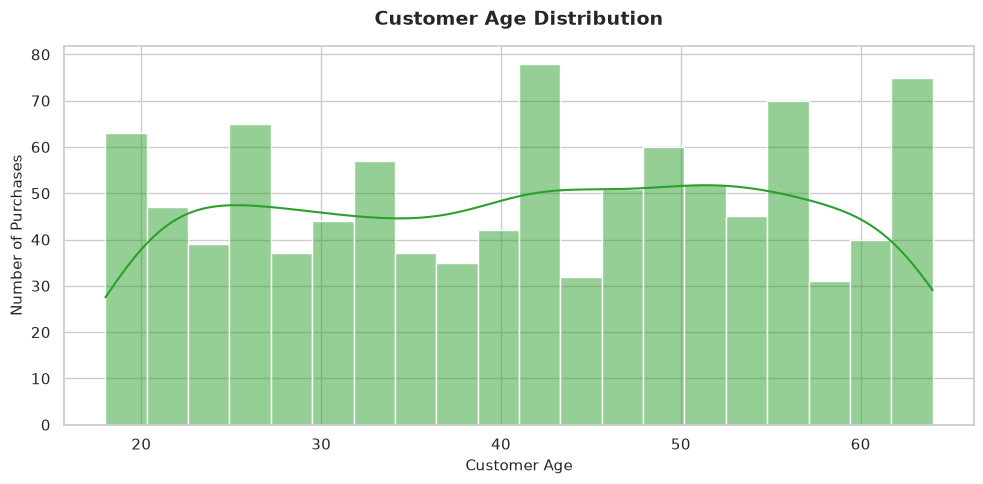

In [4]:
import os

# 0. Ensure the visuals folder exists
os.makedirs('visuals', exist_ok=True)

# Configure default chart size
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# CHART A: Monthly Revenue Trend
# ==========================================
plt.figure(figsize=(12, 5))

# Grouping data by month
sales_trend = df.groupby('Month_Year')['Total Amount'].sum().reset_index()
sales_trend['Month_Year'] = sales_trend['Month_Year'].astype(str)

# Plotting the line chart
sns.lineplot(
    data=sales_trend, 
    x='Month_Year', 
    y='Total Amount', 
    marker='o', 
    color='#1f77b4', 
    linewidth=2.5
)

plt.title("Monthly Revenue Trend (2023)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Month (2023)", fontsize=11)
plt.ylabel("Total Sales ($)", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()

# Save image for GitHub
plt.savefig('visuals/01_evolution_ventes.png', dpi=300)
plt.show()


# ==========================================
# CHART B: Revenue by Category and Gender
# ==========================================
plt.figure(figsize=(10, 6))

# Plotting the grouped bar chart
sns.barplot(
    data=df, 
    x='Product Category', 
    y='Total Amount', 
    hue='Gender', 
    estimator=sum, 
    errorbar=None, 
    palette='Set2'
)

plt.title("Revenue Breakdown by Product Category & Gender", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Product Category", fontsize=11)
plt.ylabel("Total Sales ($)", fontsize=11)
plt.legend(title="Gender")
plt.tight_layout()

# Save image for GitHub
plt.savefig('visuals/02_ventes_par_categorie_genre.png', dpi=300)
plt.show()


# ==========================================
# CHART C: Customer Age Distribution
# ==========================================
plt.figure(figsize=(10, 5))

# Plotting the histogram with a Kernel Density Estimate (KDE) line
sns.histplot(data=df, x='Age', kde=True, color='#2ca02c', bins=20)

plt.title("Customer Age Distribution", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Customer Age", fontsize=11)
plt.ylabel("Number of Purchases", fontsize=11)
plt.tight_layout()

# Save image for GitHub
plt.savefig('visuals/03_distribution_age.png', dpi=300)
plt.show()